# Exploration and Data Loading

## About the dataset

Each row is one customer. The target is `Churn` (Yes/No = did the customer leave last month).

Feature groups:
- **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Account / financial:** `tenure`, `Contract`, `PaymentMethod`, `PaperlessBilling`, `MonthlyCharges`, `TotalCharges`
- **Services:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# load dataset
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

In [15]:
file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = load_data(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [17]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [18]:
# handle missing values
for col in df.columns:
    number_null = df.loc[:, col].isnull().sum()
    percent_null = (number_null / df.shape[0]) * 100
    print(f"{col} - {number_null} - {percent_null}%")

customerID - 0 - 0.0%
gender - 0 - 0.0%
SeniorCitizen - 0 - 0.0%
Partner - 0 - 0.0%
Dependents - 0 - 0.0%
tenure - 0 - 0.0%
PhoneService - 0 - 0.0%
MultipleLines - 0 - 0.0%
InternetService - 0 - 0.0%
OnlineSecurity - 0 - 0.0%
OnlineBackup - 0 - 0.0%
DeviceProtection - 0 - 0.0%
TechSupport - 0 - 0.0%
StreamingTV - 0 - 0.0%
StreamingMovies - 0 - 0.0%
Contract - 0 - 0.0%
PaperlessBilling - 0 - 0.0%
PaymentMethod - 0 - 0.0%
MonthlyCharges - 0 - 0.0%
TotalCharges - 0 - 0.0%
Churn - 0 - 0.0%


In [19]:
# handle duplicate rows
duplicate_rows = df.duplicated()

if duplicate_rows.any():
    print("duplication exists")
else:
    print("no duplication")

no duplication


In [20]:
# sanity check for numerical cols
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numeric_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [32]:
# sanity check for categorical cols
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

def cat_check(index):
    values = np.sort(df[cat_cols[index]].unique())
    return cat_cols[index], values

In [40]:
cat_check(5)

('MultipleLines', array(['No', 'No phone service', 'Yes'], dtype=object))

In [41]:
cat_check(6)

('InternetService', array(['DSL', 'Fiber optic', 'No'], dtype=object))

In [42]:
cat_check(7)

('OnlineSecurity', array(['No', 'No internet service', 'Yes'], dtype=object))

In [43]:
cat_check(8)

('OnlineBackup', array(['No', 'No internet service', 'Yes'], dtype=object))

In [48]:
cat_check(13)

('Contract', array(['Month-to-month', 'One year', 'Two year'], dtype=object))

## Class balance

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


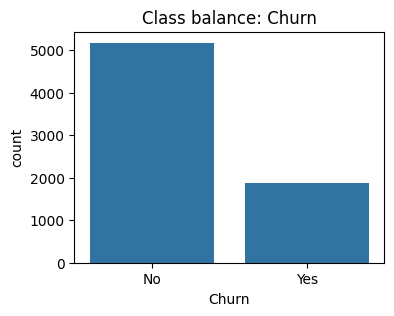

In [25]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='Churn')
plt.title('Class balance: Churn')
plt.show()

Roughly **26–27% of customers churn** → the classes are imbalanced. That's why later we optimize **recall** (not accuracy), use class weighting / `scale_pos_weight`, and tune the decision **threshold** below 0.5.

In [23]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**Observation:** most categorical variables have 2, 3, or 4 categories.
- The 2-category (binary) ones → map to 0/1.
- The 3–4 category ones → one-hot encode.

TotalCharges` loads as a string (blanks for tenure-0 customers). We coerce a *temporary* numeric copy just so we can plot it

In [26]:
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_eda[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


## Numeric feature distributions by churn (KDE)

KDE = smoothed histogram. Overlaying churn vs. no-churn shows where the groups separate.

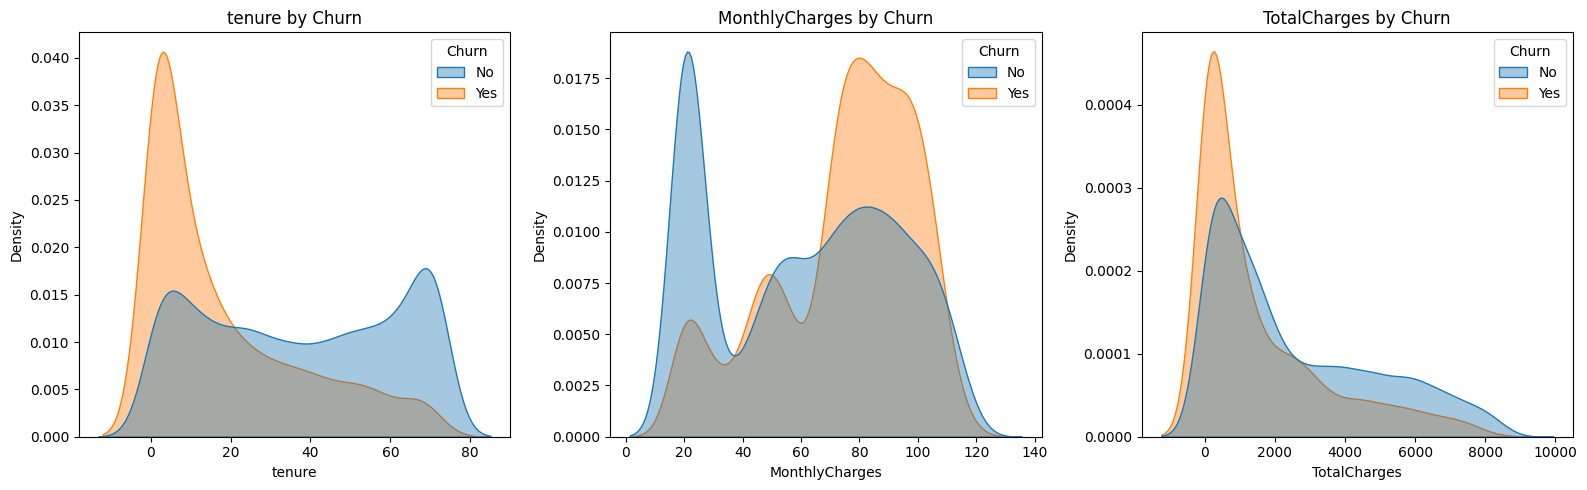

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df_eda, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

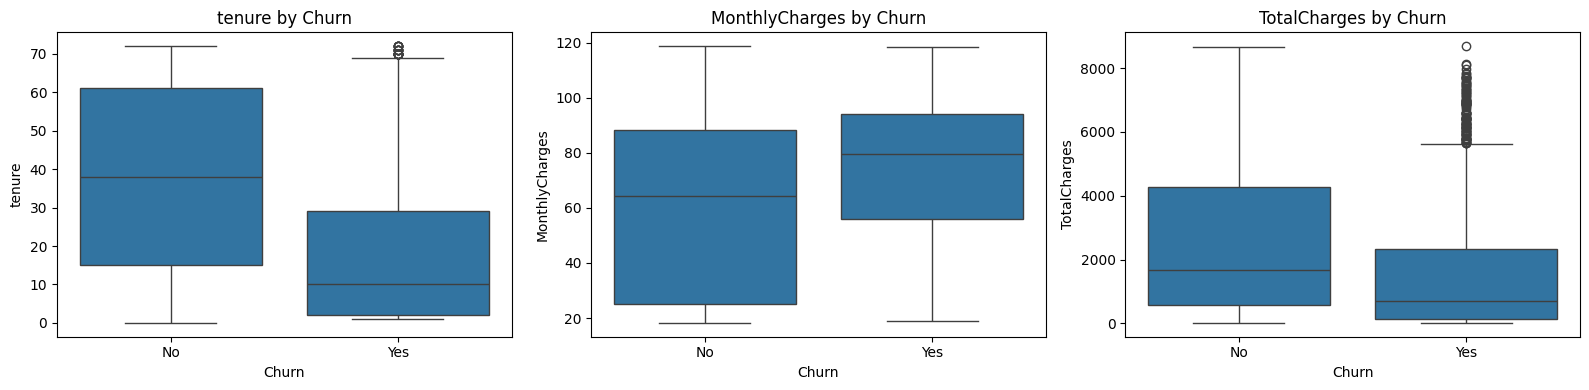

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_eda, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

## Correlation among numeric features

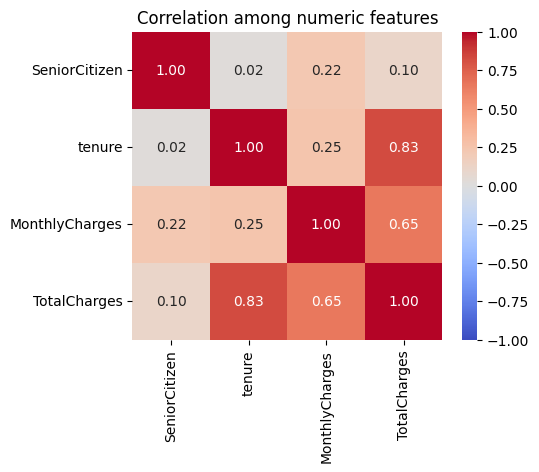

In [30]:
num_for_corr = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
corr = df_eda[num_for_corr].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation among numeric features')
plt.show()

- `tenure` and `TotalCharges` are highly correlated
- Numeric features clearly separate by churn → they'll carry real predictive weight.

In [31]:
%store df

Stored 'df' (DataFrame)
